In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Libraries
# from imblearn.over_sampling import SMOTE # To handel impbalanced data
# from collections import Counter # To check the balance of dataset
# from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix

from itertools import product

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow
from mlflow.tracking import MlflowClient
from pathlib import Path

ARTIFACT_ROOT = Path("mlruns").absolute()

PRIMARY_METRIC = "CSI"
TARGET_COL = "TH"
THRESHOLD = 0.6
EXPERIMENT_NAME = 'Thunderstorm_Prediction'
tracking_uri = Path("mlruns").absolute().as_uri()
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(EXPERIMENT_NAME)
OUTPUT_DIR = Path("models")
OUTPUT_DIR.mkdir(exist_ok=True)

client = MlflowClient()
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
experiment_id = experiment.experiment_id

In [12]:
def export_best_model(model_name: str):
    runs = client.search_runs(
        experiment_ids=[experiment_id],
        filter_string=f"tags.mlflow.runName = '{model_name}'",
        order_by=[f"metrics.{PRIMARY_METRIC} DESC"],
        max_results=1
    )

    if not runs:
        raise ValueError(f"No runs found for {model_name}")

    best_run = runs[0]
    run_id = best_run.info.run_id

    print(f"Best {model_name} run_id:", run_id)
    print(f"Best CSI:", best_run.data.metrics.get(PRIMARY_METRIC))

    dst_path = OUTPUT_DIR / model_name.lower()
    dst_path.mkdir(exist_ok=True)

    mlflow.artifacts.download_artifacts(
        run_id=run_id,
        artifact_path="best_model",
        dst_path=dst_path
    )

    print(f"Model saved to: {dst_path.resolve()}")


In [2]:
def evaluate_model_with_threshold(model, X_val, y_val, threshold=0.6):
    probs = model.predict_proba(X_val)[:, 1]
    preds = (probs >= threshold).astype(int)

    cm = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()

    pod = tp / (tp + fn) if (tp + fn) else 0
    far = fp / (tp + fp) if (tp + fp) > 0 else 0
    csi = tp / (tp + fp + fn) if (tp + fp + fn) else 0
    hss = 2 * (tp * tn - fn * fp) / (
        (tp + fn) * (fp + tn) + (tp + fp) * (fn + tn)
    ) if ((tp + fn) * (fp + tn) + (tp + fp) * (fn + tn)) else 0

    return {
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds),
        "Recall": recall_score(y_val, preds),
        "F1": f1_score(y_val, preds),
        "POD": pod,
        "FAR": far,
        "CSI": csi,
        "HSS": hss
    }


In [3]:
def run_experiments(
    model_name,
    model_class,
    param_grid,
    fixed_params,
    X_train, y_train,
    X_val, y_val,
    threshold=0.5
):
    results = []

    for params in product(*param_grid.values()):
        run_params = dict(zip(param_grid.keys(), params))

        model = model_class(**run_params, **fixed_params)
        model.fit(X_train, y_train)

        metrics = evaluate_model_with_threshold(
            model, X_val, y_val, threshold
        )

        record = {
            "Model": model_name,
            **run_params,
            **metrics
        }
        results.append(record)

    return pd.DataFrame(results)


In [4]:
def run_and_log_experiment_clean(
    model_name,
    model_class,
    param_grid,
    fixed_params,
    X_train, y_train,
    X_val, y_val,
    threshold,
    primary_metric
):
    results = []
    best_score = -np.inf
    best_model = None
    best_params = None

    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model", model_name)
        mlflow.log_param("threshold", threshold)
        mlflow.log_param("n_features", X_train.shape[1])

        for params in product(*param_grid.values()):
            run_params = dict(zip(param_grid.keys(), params))
            model = model_class(**run_params, **fixed_params)
            model.fit(X_train, y_train)

            metrics = evaluate_model_with_threshold(
                model, X_val, y_val, threshold
            )

            results.append({**run_params, **metrics})

            score = metrics[primary_metric]
            if score > best_score:
                best_score = score
                best_model = model
                best_params = run_params

        # Log best metrics
        mlflow.log_metric(f"best_{primary_metric}", best_score)

        # Log best params
        for k, v in best_params.items():
            mlflow.log_param(f"best_{k}", v)

        # Save grid results ONCE
        results_df = pd.DataFrame(results)
        results_path = f"{model_name}_grid_results.csv"
        results_df.to_csv(results_path, index=False)
        mlflow.log_artifact(results_path)

        # Log ONLY the best model
        if model_name == "XGBoost":
            mlflow.xgboost.log_model(best_model, artifact_path="best_model")
        else:
            mlflow.sklearn.log_model(best_model, artifact_path="best_model")

    return results_df


# Importing Data

In [35]:
indices_df = pd.read_csv("../raw_data/indices_data.csv")
surface_df = pd.read_csv("../raw_data/surface_data.csv")

# Data Exploration

## Data Understanding

In [36]:
print(indices_df.describe())
surface_df.describe()

               Year         Month           Day   SWEAT index  \
count  11883.000000  11883.000000  11883.000000  11883.000000   
mean    1998.286712      6.539510     15.728099    182.923858   
std       11.154318      3.433968      8.819977     92.033776   
min     1981.000000      1.000000      1.000000      5.800000   
25%     1989.000000      4.000000      8.000000    104.600000   
50%     1997.000000      7.000000     16.000000    185.300000   
75%     2005.500000     10.000000     23.000000    249.050000   
max     2020.000000     12.000000     31.000000    850.700000   

       Showalter index  LIFTED index       K index  Cross totals index  \
count     11883.000000  11883.000000  11883.000000        11883.000000   
mean          6.931743      0.521754     23.206581           15.603484   
std           4.465433      7.002176     15.823667            7.171165   
min          -9.600000    -21.700000    -62.300000          -36.700000   
25%           4.100000     -4.300000     11.

,Year,Month,Day
count,14397.000000,14397.000000,14397.000000
mean,2000.326179,6.517052,15.727026
std,11.426269,3.452945,8.800485
min,1981.000000,1.000000,1.000000
25%,1990.000000,4.000000,8.000000
50%,2000.000000,7.000000,16.000000
75%,2010.000000,10.000000,23.000000
max,2020.000000,12.000000,31.000000


In [37]:
print(indices_df.info())
surface_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11883 entries, 0 to 11882
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   11883 non-null  int64  
 1   Month                  11883 non-null  int64  
 2   Day                    11883 non-null  int64  
 3   SWEAT index            11883 non-null  float64
 4   Showalter index        11883 non-null  float64
 5   LIFTED index           11883 non-null  float64
 6   K index                11883 non-null  float64
 7   Cross totals index     11883 non-null  float64
 8   Vertical totals index  11883 non-null  float64
 9   Totals totals index    11883 non-null  float64
 10  TLCL                   11883 non-null  float64
 11  PLCL                   11883 non-null  float64
 12  CINE                   11883 non-null  float64
 13  CAPE                   11883 non-null  float64
 14  PRECIPITABLE WATER     11883 non-null  float64
 15  10

In [38]:
print(surface_df.head(5))
indices_df.head(5)

   Year  Month  Day HA TH Unnamed: 5
0  1981      1    1  0  0           
1  1981      1    2  0  0           
2  1981      1    3  0  0           
3  1981      1    4  0  0           
4  1981      1    5  0  0           


,Year,Month,Day,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS
0,1981,1,1,91.2,12.4,13.4,-1.4,3.0,21.7,24.7,284.41,993.98,0.0,0.0,22.8,5636
1,1981,1,2,75.7,10.2,11.3,1.6,10.2,20.1,30.3,282.11,956.13,0.0,0.0,20.4,5592
2,1981,1,4,128.3,6.9,6.9,17.5,16.3,25.3,41.6,284.79,978.71,0.0,0.0,23.8,5581
3,1981,1,5,194.2,2.8,1.2,23.5,22.5,28.1,50.6,286.68,965.77,-138.5,83.1,28.6,5578
4,1981,1,6,151.4,5.1,1.8,25.4,18.9,24.9,43.8,289.11,975.72,-112.9,47.9,33.2,5648


In [39]:
print(surface_df.count())
indices_df.count()

Year          14397
Month         14397
Day           14397
HA            14396
TH            14396
Unnamed: 5    14397
dtype: int64


Year                     11883
Month                    11883
Day                      11883
SWEAT index              11883
Showalter index          11883
LIFTED index             11883
K index                  11883
Cross totals index       11883
Vertical totals index    11883
Totals totals index      11883
TLCL                     11883
PLCL                     11883
CINE                     11883
CAPE                     11883
PRECIPITABLE WATER       11883
1000-500 THICKNESS       11883
dtype: int64

In [40]:
print(surface_df.isna().sum())
indices_df.isna().sum()

Year          0
Month         0
Day           0
HA            1
TH            1
Unnamed: 5    0
dtype: int64


Year                     0
Month                    0
Day                      0
SWEAT index              0
Showalter index          0
LIFTED index             0
K index                  0
Cross totals index       0
Vertical totals index    0
Totals totals index      0
TLCL                     0
PLCL                     0
CINE                     0
CAPE                     0
PRECIPITABLE WATER       0
1000-500 THICKNESS       0
dtype: int64

## Thunderstorm Count

In [41]:
th_count = surface_df['TH'].value_counts()
th_count

TH
0    11623
1     2772
         1
Name: count, dtype: int64

## Combining 'Year','Month','Day' columns to create single Date Column in dd/mm/YYYY format

In [ ]:
indices_df['Date'] = pd.to_datetime(indices_df[['Year','Month','Day']]).dt.strftime('%d/%m/%Y')
surface_df['Date'] = pd.to_datetime(surface_df[['Year','Month','Day']]).dt.strftime('%d/%m/%Y')

In [ ]:
surface_df.drop(columns=['Year','Month','Day', 'Unnamed: 5'], inplace=True)
indices_df.drop(columns=['Year','Month','Day'], inplace=True)

## Performing Inner Join on Surface and Indices data on Date Column

In [ ]:
merged_df = pd.merge(indices_df, surface_df, how='inner', on='Date')
merged_df.to_csv('raw_data/merged_idf_sdf.csv', index=False)

In [54]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11682 entries, 0 to 11681
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SWEAT index            11682 non-null  float64
 1   Showalter index        11682 non-null  float64
 2   LIFTED index           11682 non-null  float64
 3   K index                11682 non-null  float64
 4   Cross totals index     11682 non-null  float64
 5   Vertical totals index  11682 non-null  float64
 6   Totals totals index    11682 non-null  float64
 7   TLCL                   11682 non-null  float64
 8   PLCL                   11682 non-null  float64
 9   CINE                   11682 non-null  float64
 10  CAPE                   11682 non-null  float64
 11  PRECIPITABLE WATER     11682 non-null  float64
 12  1000-500 THICKNESS     11682 non-null  int64  
 13  Date                   11682 non-null  object 
 14  HA                     11681 non-null  object 
 15  TH

In [2]:
merger_df = pd.read_csv('../raw_data/merged_idf_sdf.csv')

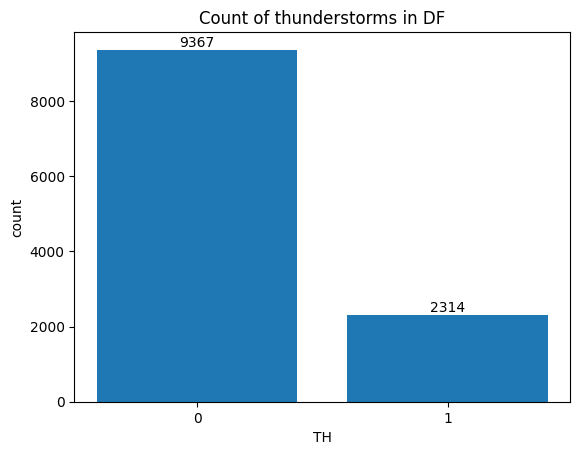

In [6]:
th_count = merger_df['TH'].value_counts()

# Plotting the count of Thunderstorms
plt.bar(th_count.index, th_count.values)

# Plot Labels
plt.xlabel('TH')
plt.ylabel('count')
plt.title("Count of thunderstorms in DF")

# customizing X-axis tick Labels
plt.xticks([0, 1], ['0', '1'])

# adding count labelson top of each bar
for i, count in enumerate(th_count.values):
    plt.text(i, count, str(count), ha='center', va='bottom')

plt.show()

## Feature updation and Selection

In [2]:
merger_df = pd.read_csv('../raw_data/merged_idf_sdf.csv')

In [3]:
# Renaming and combining columns
merger_df['env_stability'] = merger_df['Showalter index'] + merger_df['LIFTED index']
merger_df['moisture_indices']  = merger_df['PRECIPITABLE WATER']
merger_df['convictive_potential']  = merger_df['CAPE'] + merger_df['CINE']
merger_df['temp_pressure']  = merger_df['1000-500 THICKNESS']
merger_df['moisture_temp_profile']  = merger_df['PLCL']

# dropping the un-neccessary columns
merger_df.drop(columns=['Showalter index','LIFTED index','PRECIPITABLE WATER','CAPE','CINE','1000-500 THICKNESS','PLCL', 'Cross totals index', 'Vertical totals index'], inplace=True)

In [4]:
merger_df.head()

,SWEAT index,K index,Totals totals index,TLCL,Date,HA,TH,env_stability,moisture_indices,convictive_potential,temp_pressure,moisture_temp_profile
0,91.2,-1.4,24.7,284.41,01/01/1981,0.0,0.0,25.8,22.8,0.0,5636,993.98
1,75.7,1.6,30.3,282.11,02/01/1981,0.0,0.0,21.5,20.4,0.0,5592,956.13
2,128.3,17.5,41.6,284.79,04/01/1981,0.0,0.0,13.8,23.8,0.0,5581,978.71
3,194.2,23.5,50.6,286.68,05/01/1981,0.0,0.0,4.0,28.6,-55.4,5578,965.77
4,151.4,25.4,43.8,289.11,06/01/1981,0.0,0.0,6.9,33.2,-65.0,5648,975.72


In [5]:
# Sending the Dependent Ccolumn at the end
columns = list(merger_df.columns)
for col in ['TH', 'HA']:
    columns.remove(col)

columns.extend(['TH', 'HA'])
merger_df = merger_df[columns]

merger_df.isna().sum()
for col in ['TH', 'HA']:
    merger_df[col] = merger_df[col].fillna(merger_df[col].mode()[0])

In [9]:
merger_df.columns

Index(['SWEAT index', 'K index', 'Totals totals index', 'TLCL', 'Date',
       'env_stability', 'moisture_indices', 'convictive_potential',
       'temp_pressure', 'moisture_temp_profile', 'TH', 'HA'],
      dtype='object')

In [10]:
merger_df.head(10)

,SWEAT index,K index,Totals totals index,TLCL,Date,env_stability,moisture_indices,convictive_potential,temp_pressure,moisture_temp_profile,TH,HA
0,91.2,-1.4,24.7,284.41,01/01/1981,25.8,22.8,0.0,5636,993.98,0.0,0.0
1,75.7,1.6,30.3,282.11,02/01/1981,21.5,20.4,0.0,5592,956.13,0.0,0.0
2,128.3,17.5,41.6,284.79,04/01/1981,13.8,23.8,0.0,5581,978.71,0.0,0.0
3,194.2,23.5,50.6,286.68,05/01/1981,4.0,28.6,-55.4,5578,965.77,0.0,0.0
4,151.4,25.4,43.8,289.11,06/01/1981,6.9,33.2,-65.0,5648,975.72,0.0,0.0
5,287.4,35.7,53.8,290.75,07/01/1981,-6.0,32.2,677.6,5590,988.05,0.0,0.0
6,93.6,12.0,32.6,285.79,08/01/1981,16.8,25.5,0.0,5591,988.33,0.0,0.0
7,87.2,14.1,32.6,284.30,09/01/1981,14.4,23.0,24.4,5540,960.95,0.0,0.0
8,67.9,14.8,35.0,280.73,10/01/1981,23.9,24.1,0.0,5603,928.51,0.0,0.0
9,64.0,22.6,29.5,282.80,11/01/1981,13.8,22.0,0.0,5599,936.57,0.0,0.0


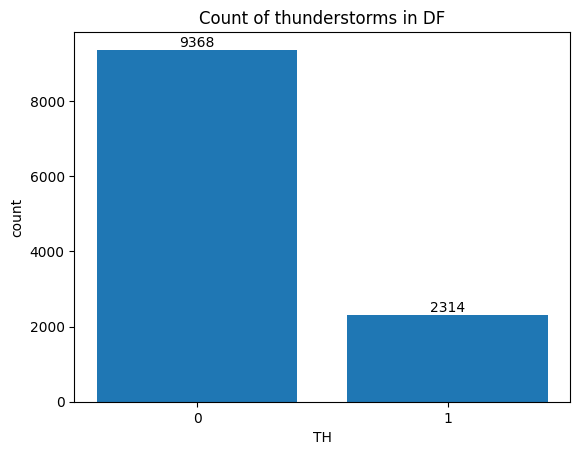

In [8]:
th_count = merger_df['TH'].value_counts()

# Plotting the count of Thunderstorms
plt.bar(th_count.index, th_count.values)

# Plot Labels
plt.xlabel('TH')
plt.ylabel('count')
plt.title("Count of thunderstorms in DF")

# customizing X-axis tick Labels
plt.xticks([0, 1], ['0', '1'])

# adding count labelson top of each bar
for i, count in enumerate(th_count.values):
    plt.text(i, count, str(count), ha='center', va='bottom')

plt.show()

merger_df.to_csv('../raw_data/final_id_sd.csv', index=False)

# Model Training


## Spliting the Data

I am doing a data based split rather than traditional train_test_split because randomling spliting the data will introduce data leakage and model learning the future patterns which can result in model learning from dataset on various time periods rather than based on temporal patterns

Below is my older split code

X = merger_df.drop(columns='TH')
Y = merger_df[['TH']]

# 1️⃣ Split out the final test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, Y,
    test_size=0.15,
    random_state=42
)

# 2️⃣ Split remaining 85% into train (75%) and val (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.118,   # 10 / 85
    random_state=42
)

# Using SMOTE to resample the imbalanced data
smote = SMOTE()
X_train_resam, y_train_resam = smote.fit_resample(X_train, y_train)

print(len(X_train_resam), len(y_train_resam))
print(len(X_test), len(y_test))
print(len(X_val), len(y_val))
Result of the above prints
14006 14006
1753 1753
1172 1172

print(Counter(y_train_resam['TH']))
print(Counter(y_val['TH']))
print(Counter(y_test['TH']))
Result of the above prints
Counter({0.0: 7003, 1.0: 7003})
Counter({0.0: 943, 1.0: 229})
Counter({0.0: 1422, 1.0: 331})

In [9]:
merger_df = pd.read_csv('../raw_data/final_id_sd.csv')

In [12]:
n = len(merger_df)

train_end = int(0.75 * n)
val_end   = int(0.85 * n)

train_df = merger_df.iloc[:train_end]
val_df   = merger_df.iloc[train_end:val_end]
test_df  = merger_df.iloc[val_end:]

In [13]:
X_train = train_df.drop(columns=['TH', 'HA', 'Date'])
y_train = train_df['TH']

X_val = val_df.drop(columns=['TH', 'HA', 'Date'])
y_val = val_df['TH']

X_test = test_df.drop(columns=['TH', 'HA', 'Date'])
y_test = test_df['TH']

## Model Creation and testing

## Random Forest

In [14]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 12, None],
    "min_samples_leaf": [3, 5, 10]
}

rf_fixed_params = {
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
}

rf_results_df = run_experiments(
    model_name="RandomForest",
    model_class=RandomForestClassifier,
    param_grid=rf_param_grid,
    fixed_params=rf_fixed_params,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

best_rf = rf_results_df.sort_values(PRIMARY_METRIC, ascending=False).iloc[0]


## XGBoost

In [15]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgb_param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_fixed_params = {
    "n_estimators": 300,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1
}

xgb_results_df = run_experiments(
    model_name="XGBoost",
    model_class=XGBClassifier,
    param_grid=xgb_param_grid,
    fixed_params=xgb_fixed_params,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

best_xgb = xgb_results_df.sort_values(PRIMARY_METRIC, ascending=False).iloc[0]


C:\Users\Shubham\AppData\Local\Temp\ipykernel_15380\2218593404.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  neg, pos = np.bincount(y_train)


## Logistic Regression

In [16]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

lr_fixed_params = {
    "penalty": "l2",
    "solver": "liblinear",
    "class_weight": "balanced",
    "max_iter": 1000
}

lr_results_df = run_experiments(
    model_name="LogisticRegression",
    model_class=LogisticRegression,
    param_grid=lr_param_grid,
    fixed_params=lr_fixed_params,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

best_lr = lr_results_df.sort_values(PRIMARY_METRIC, ascending=False).iloc[0]


c:\Users\Shubham\Documents\Python Scripts\KrishNaik Projects\Beginner\thunderstorm_forcasting\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Shubham\Documents\Python Scripts\KrishNaik Projects\Beginner\thunderstorm_forcasting\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Shubham\Documents\Python Scripts\KrishNaik Projec

# ML FLOW Tracking

In [18]:
n_features = X_train.shape[1]

In [20]:
rf_results_df = run_and_log_experiment_clean(
    model_name="RandomForest",
    model_class=RandomForestClassifier,
    param_grid=rf_param_grid,
    fixed_params=rf_fixed_params,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    threshold=THRESHOLD,
    # target_col=TARGET_COL,
    primary_metric=PRIMARY_METRIC
)


2026/02/03 23:37:20 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/02/03 23:38:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instea

In [21]:
xgb_results_df = run_and_log_experiment_clean(
    model_name="XGBoost",
    model_class=XGBClassifier,
    param_grid=xgb_param_grid,
    fixed_params=xgb_fixed_params,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    threshold=THRESHOLD,
    # target_col=TARGET_COL,
    primary_metric=PRIMARY_METRIC
)


2026/02/03 23:39:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/03 23:39:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [22]:
lr_results_df = run_and_log_experiment_clean(
    model_name="LogisticRegression",
    model_class=LogisticRegression,
    param_grid=lr_param_grid,
    fixed_params=lr_fixed_params,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    threshold=THRESHOLD,
    # target_col=TARGET_COL,
    primary_metric=PRIMARY_METRIC
)


c:\Users\Shubham\Documents\Python Scripts\KrishNaik Projects\Beginner\thunderstorm_forcasting\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Shubham\Documents\Python Scripts\KrishNaik Projects\Beginner\thunderstorm_forcasting\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Shubham\Documents\Python Scripts\KrishNaik Projec

In [23]:
print("CODE tracking URI:", mlflow.get_tracking_uri())

CODE tracking URI: file:///c:/Users/Shubham/Documents/Python%20Scripts/KrishNaik%20Projects/Beginner/thunderstorm_forcasting/notebooks/mlruns


In [15]:
PRIMARY_METRIC = "best_CSI"
export_best_model("RandomForest")
export_best_model("XGBoost")
export_best_model("LogisticRegression")


Best RandomForest run_id: fe9addf8534948a98d9bd80f392a9ac2
Best CSI: 0.32426778242677823
Model saved to: C:\Users\Shubham\Documents\Python Scripts\KrishNaik Projects\Beginner\thunderstorm_forcasting\notebooks\models\randomforest
Best XGBoost run_id: f368cea0307c498ea6fab17a12d72107
Best CSI: 0.33013435700575816
Model saved to: C:\Users\Shubham\Documents\Python Scripts\KrishNaik Projects\Beginner\thunderstorm_forcasting\notebooks\models\xgboost
Best LogisticRegression run_id: 8cf59f11e35b49dcb91727bff2ce8115
Best CSI: 0.32727272727272727
Model saved to: C:\Users\Shubham\Documents\Python Scripts\KrishNaik Projects\Beginner\thunderstorm_forcasting\notebooks\models\logisticregression


In [13]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    metrics = evaluate_model(model, X_val, y_val, threshold=0.5)
    metrics["Model"] = name

    results.append(metrics)

c:\Users\Shubham\Documents\Python Scripts\KrishNaik Projects\Beginner\thunderstorm_forcasting\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [17]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model").round(3)

results_df.sort_values("CSI", ascending=False)

,Accuracy,Precision,Recall,F1,POD,FAR,CSI,HSS
Model,,,,,,,,
Random Forest,0.675,0.350,0.773,0.482,0.773,0.349,0.318,0.331
XGBoost,0.670,0.345,0.755,0.473,0.755,0.350,0.310,0.317
Logistic Regression,0.621,0.324,0.860,0.471,0.860,0.438,0.308,0.327
Gradient Boosting,0.792,0.422,0.166,0.238,0.166,0.055,0.135,0.152


In [27]:
# Subject matter expert Metrices
total_pos = cm[1].sum()
total_neg = cm[0].sum()
true_pos = cm[1][1]
false_pos = cm[0][1]
false_neg = cm[1][0]
true_neg = cm[0][0]

pod = true_pos/total_pos # Prob of detection
far = false_pos/total_neg # False Alarm Rate

hss = 2 * ((true_pos * true_neg) - (false_neg * false_pos)) / (
    (true_pos + false_neg) * (false_pos + true_neg) + 
    (true_pos + false_pos) * (false_neg + true_neg))
csi = true_pos / ( true_pos + false_pos + false_neg  ) # Critical success index

In [28]:
print("Accuracy", accuracy)
print("Presission", precision)
print("F1", f1)
print("Recall", recall)
print("-" * 60)
print("POD", pod)
print("FAR", far)
print("CSI", csi)
print("HSS", hss)


Accuracy 0.6746575342465754
Presission 0.3504950495049505
F1 0.4822888283378747
Recall 0.7729257641921398
------------------------------------------------------------
POD 0.7729257641921398
FAR 0.34930777422790205
CSI 0.3177737881508079
HSS 0.3313327731764894


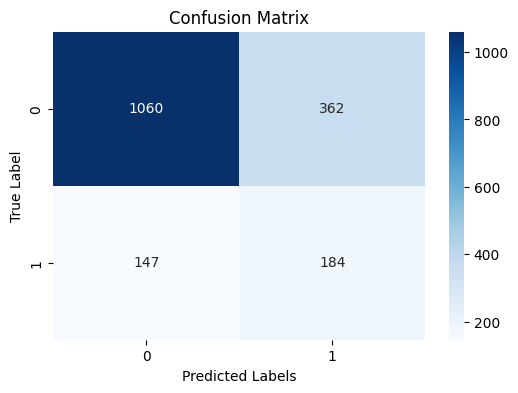

In [24]:
# Printing Confusion Matrix
prediction = model.predict(X_test)
prediction = np.where(prediction.flatten() > 0.6, 1, 0)

result_df = pd.DataFrame(data = X_test, columns=X_test.columns)
result_df['True Label'] = Y
result_df['Prediction Label'] = prediction

True_label = result_df['True Label']
prediction_label = result_df['Prediction Label']

confusion_mat = confusion_matrix(True_label, prediction_label)

plt.figure(figsize=(6,4))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Labels')
plt.ylabel('True Label')
plt.title("Confusion Matrix")

plt.show()